**Load and Understand Data**

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_excel('/content/drive/MyDrive/Retail Sales & Customer Segmentation Project/online_retail_II.xlsx', sheet_name=0)

# First look at the data
print(df.shape)          # how many rows/columns
print(df.head())         # first 5 rows
print(df.info())         # data types, missing values
print(df.describe())     # basic statistics for numeric columns

(525461, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----       

**Clean The Data**

In [ ]:
# 1. Check how many invoices are cancellations (start with 'C')
df['Invoice'] = df['Invoice'].astype(str)
cancelled = df[df['Invoice'].str.startswith('C')]
print(f"Cancelled transactions: {len(cancelled)}")

# 2. Remove cancelled orders (we'll analyze these separately later if needed)
df_clean = df[~df['Invoice'].str.startswith('C')].copy()

# 3. Remove rows with missing Description
df_clean = df_clean.dropna(subset=['Description'])

# 4. Remove rows with negative or zero Price (bad debt adjustments, not real sales)
df_clean = df_clean[df_clean['Price'] > 0]

# 5. Remove rows with negative or zero Quantity (shouldn't be any left after removing cancellations, but double-check)
df_clean = df_clean[df_clean['Quantity'] > 0]

# 6. Create a 'TotalPrice' column — this is critical for revenue analysis
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

# 7. Check the result
print(df_clean.shape)
print(df_clean.isnull().sum())
print(df_clean.describe())

Cancelled transactions: 10206
(511565, 9)
Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID    103901
Country             0
TotalPrice          0
dtype: int64
           Quantity                    InvoiceDate          Price  \
count  511565.00000                         511565  511565.000000   
mean       11.40017  2010-06-28 22:20:55.320946688       4.251841   
min         1.00000            2009-12-01 07:45:00       0.001000   
25%         1.00000            2010-03-21 15:22:00       1.250000   
50%         3.00000            2010-07-07 09:41:00       2.100000   
75%        10.00000            2010-10-15 15:06:00       4.210000   
max     19152.00000            2010-12-09 20:01:00   25111.090000   
std        86.76126                            NaN      63.662597   

         Customer ID     TotalPrice  
count  407664.000000  511565.000000  
mean    15368.592598      20.145811  
min     123

**Save The Cleaned Data**

In [ ]:
import os

# Create the directory if it doesn't exist
os.makedirs('../data/processed', exist_ok=True)

# Save cleaned data to the processed folder
df_clean.to_csv('../data/processed/cleaned_retail_data.csv', index=False)
print("Saved successfully!")

Saved successfully!


**1.What does revenue look like over time?**

InvoiceMonth
2009-12     825685.760
2010-01     652708.502
2010-02     553339.736
2010-03     833570.131
2010-04     681528.992
2010-05     659858.860
2010-06     752270.140
2010-07     650712.940
2010-08     697274.910
2010-09     924333.011
2010-10    1165483.910
2010-11    1470272.482
2010-12     438852.650
Freq: M, Name: TotalPrice, dtype: float64


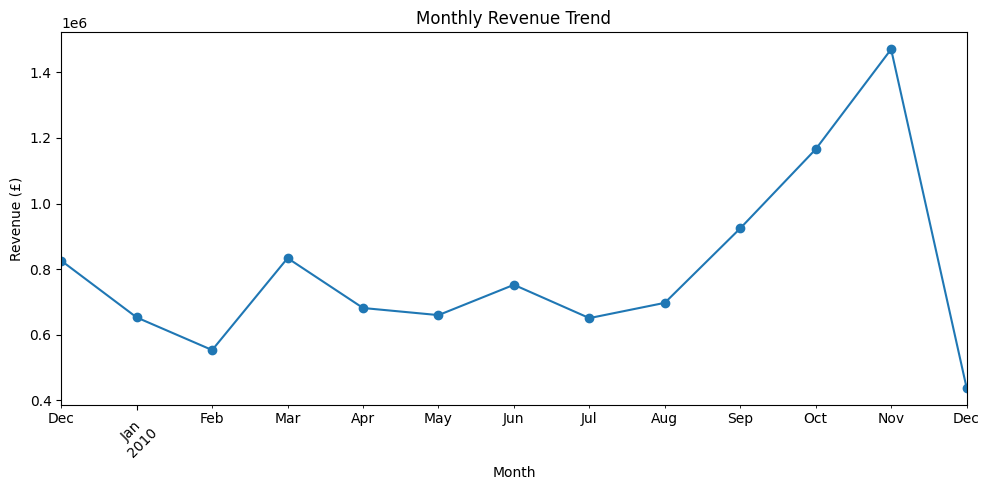

In [ ]:
import matplotlib.pyplot as plt

# Create a 'Month' column to group sales by month
df_clean['InvoiceMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

# Group by month and sum revenue
monthly_revenue = df_clean.groupby('InvoiceMonth')['TotalPrice'].sum()

print(monthly_revenue)

# Plot it
monthly_revenue.plot(kind='line', marker='o', figsize=(10,5), title='Monthly Revenue Trend')
plt.ylabel('Revenue (£)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Top Products And Top Companies**

In [ ]:
# Top 10 best-selling products by revenue
top_products = df_clean.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print("Top 10 Products by Revenue:")
print(top_products)

# Top 10 countries by revenue
top_countries = df_clean.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Countries by Revenue:")
print(top_countries)

# Bonus: revenue by day of week (helps understand shopping patterns)
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()
revenue_by_day = df_clean.groupby('DayOfWeek')['TotalPrice'].sum().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    )
print("\nRevenue by Day of Week:")
print(revenue_by_day)

Top 10 Products by Revenue:
Description
Manual                                 262618.51
REGENCY CAKESTAND 3 TIER               170078.51
WHITE HANGING HEART T-LIGHT HOLDER     160630.78
DOTCOM POSTAGE                         116408.71
ASSORTED COLOUR BIRD ORNAMENT           73092.99
PAPER CHAIN KIT 50'S CHRISTMAS          58189.25
JUMBO BAG RED RETROSPOT                 56595.51
PARTY BUNTING                           49682.72
POSTAGE                                 49477.54
ROTATING SILVER ANGELS T-LIGHT HLDR     47985.09
Name: TotalPrice, dtype: float64

Top 10 Countries by Revenue:
Country
United Kingdom    8845755.693
EIRE               380977.820
Netherlands        268786.000
Germany            202395.321
France             147211.490
Sweden              53525.390
Denmark             50906.850
Spain               47601.420
Switzerland         43921.390
Australia           31446.800
Name: TotalPrice, dtype: float64

Revenue by Day of Week:
DayOfWeek
Monday       1865181.545
Tuesda

In [ ]:
# Check how many transactions actually happened on Saturdays
saturday_data = df_clean[df_clean['DayOfWeek'] == 'Saturday']
print(f"Number of Saturday transactions: {len(saturday_data)}")
print(f"Number of unique Saturday dates in dataset: {saturday_data['InvoiceDate'].dt.date.nunique()}")

Number of Saturday transactions: 400
Number of unique Saturday dates in dataset: 1


**Customer** **Segmentation**

In [ ]:
# Filter to only rows with a Customer ID (needed for segmentation)
df_rfm = df_clean.dropna(subset=['Customer ID']).copy()
df_rfm['Customer ID'] = df_rfm['Customer ID'].astype(int)

# Set a reference date = one day after the last transaction in the dataset
reference_date = df_rfm['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date}")

# Calculate RFM values per customer
rfm = df_rfm.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,   # Recency
        'Invoice': 'nunique',                                        # Frequency
            'TotalPrice': 'sum'                                          # Monetary
            })

rfm.columns = ['Recency', 'Frequency', 'Monetary']
print(rfm.head())
print(rfm.describe())

Reference date: 2010-12-10 20:01:00
             Recency  Frequency  Monetary
Customer ID                              
12346            165         11    372.86
12347              3          2   1323.32
12348             74          1    222.16
12349             43          3   2671.14
12351             11          1    300.93
           Recency    Frequency       Monetary
count  4312.000000  4312.000000    4312.000000
mean     91.171846     4.455705    2048.238236
std      96.860633     8.170213    8914.481280
min       1.000000     1.000000       2.950000
25%      18.000000     1.000000     307.987500
50%      53.000000     2.000000     706.020000
75%     136.000000     5.000000    1723.142500
max     374.000000   205.000000  349164.350000


**Convert RFM into Scores**

In [ ]:
# Score Recency (1 = worst/long ago, 5 = best/most recent) — reversed because lower recency is better
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# Score Frequency (1 = worst/least orders, 5 = best/most orders)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Score Monetary (1 = worst/least spend, 5 = best/most spend)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Combine into a single RFM segment string, e.g. "555" = best possible customer
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print(rfm.head(10))

             Recency  Frequency  Monetary  R_Score  F_Score  M_Score RFM_Score
Customer ID                                                                   
12346            165         11    372.86        2        5        2       252
12347              3          2   1323.32        5        2        4       524
12348             74          1    222.16        2        1        1       211
12349             43          3   2671.14        3        3        5       335
12351             11          1    300.93        5        1        2       512
12352             11          2    343.80        5        2        2       522
12353             44          1    317.76        3        1        2       312
12355            203          1    488.21        1        1        2       112
12356             16          3   3562.25        4        3        5       435
12357             24          2  12079.99        4        2        5       425


**Map scores into readable segment names**

In [ ]:
def segment_customer(row):
  r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
  if r >= 4 and f >= 4 and m >= 4:
    return 'Champions'
  elif r >= 3 and f >= 3 and m >= 3:
    return 'Loyal Customers'
  elif r >= 4 and f <= 2:
    return 'New Customers'
  elif r <= 2 and f >= 4 and m >= 4:
    return 'At Risk'
  elif r <= 2 and f <= 2 and m <= 2:
    return 'Lost'
  elif r >= 3 and f <= 2:
    return 'Promising'
  else:
    return 'Needs Attention'
rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Count how many customers fall into each segment
segment_counts = rfm['Segment'].value_counts()
print(segment_counts)

# Average monetary value per segment (helps prioritize which segments matter most)
segment_value = rfm.groupby('Segment')['Monetary'].agg(['mean', 'sum', 'count']).sort_values('sum', ascending=False)
print(segment_value)





Segment
Champions          926
Needs Attention    854
Lost               833
Loyal Customers    773
New Customers      367
Promising          343
At Risk            216
Name: count, dtype: int64
                        mean          sum  count
Segment                                         
Champions        6187.627859  5729743.397    926
Loyal Customers  1607.420093  1242535.732    773
Needs Attention   781.892872   667736.513    854
At Risk          3088.028708   667014.201    216
Lost              226.783242   188910.441    833
New Customers     503.243134   184690.230    367
Promising         441.320000   151372.760    343


**Save Data for Power BI**

In [ ]:
# Reset index so Customer ID becomes a regular column (needed for Power BI)
rfm_export = rfm.reset_index()

# Save RFM table
rfm_export.to_csv('../data/processed/rfm_segments.csv', index=False)

# Also save the full cleaned transaction data (already done earlier, just confirming path)
# df_clean.to_csv('../data/processed/cleaned_retail_data.csv', index=False)

print("Files ready for Power BI:")
print("1. cleaned_retail_data.csv - for overall sales trends")
print("2. rfm_segments.csv - for customer segmentation view")

Files ready for Power BI:
1. cleaned_retail_data.csv - for overall sales trends
2. rfm_segments.csv - for customer segmentation view
